In [61]:
from langgraph.graph import StateGraph,START,END
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel , Field
from langchain_core.messages import SystemMessage,HumanMessage
import operator 

In [62]:
generator_llm = ChatOpenRouter(
    model="qwen/qwen-2.5-7b-instruct"
)

evaluator_llm = ChatOpenRouter(
    model="qwen/qwen3-32b"
)

optimizer_llm = ChatOpenRouter(
    model="qwen/qwen3-32b"
)

In [63]:
# state
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved","needs_improvment"]
    feedback:str
    iteration:int
    max_iteration:int

    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]

In [64]:
def generate_tweet(state:TweetState) -> TweetState:

    #prompt
    messages = [
        SystemMessage(
    content="You are a funny and clever Twitter/X influencer."
        ),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        - OUTPUT ONLY THE TWEET. Do not include character counts, explanations, or introductory text. 
        - This is version {state['iteration'] + 1}.
        """)
            ]
    
    #send to generator llm
    tweet = generator_llm.invoke(messages).content

    return {'tweet':tweet,'tweet_history':[tweet]}

In [65]:
class EvaluationSchema(BaseModel):
    evaluation:Literal["approved","needs_improvment"] = Field(description="Final Evaluation Result")
    feedback:str = Field(description="Feedback for the tweet")

In [66]:
structured_evaluator_llm = evaluator_llm.with_structured_output(EvaluationSchema)

In [67]:
def evaluate_tweet(state:TweetState) -> TweetState:

    # prompt
    messages = [
    SystemMessage(
        content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."
    ),
HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:
1. Originality - Is this fresh, or have you seen it a hundred times before?
2. Humor - Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness - Is it short, sharp, and scroll-stopping?
4. Virality Potential - Would people retweet or share it?
5. Format - Is it a well-formed tweet?

CRITICAL AUTO-REJECT CRITERIA:
- Reject if the generator included ANY extra text, commentary, or explanations outside of the tweet itself (e.g., "Here is your tweet:" or "Why this works:").
- Reject if it uses hashtags that feel robotic or forced (e.g., #Relatable, #StudentLife).
- Reject if it reads like a traditional setup-punchline joke or Q&A.
- Reject if it exceeds 280 characters.
- DEFAULT TO REJECT on the first iteration unless it is an absolute masterpiece. If it is just "okay" or "mildly amusing", mark it as "needs_improvment".

Respond ONLY in this structured format:
evaluation: "approved" or "needs_improvment"
feedback: One paragraph explaining the strengths and weaknesses
""")
]
    responses = structured_evaluator_llm.invoke(messages)

    return {'evaluation':responses.evaluation, 'feedback':responses.feedback,'feedback_history':[responses.feedback]}


In [68]:
def optimize_tweet(state:TweetState) -> TweetState:

    #prompt
    messages = [
    SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
    HumanMessage(content=f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Tweet:
    {state['tweet']}

    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """)
    ]

    optimal_tweet = optimizer_llm.invoke(messages).content

    iteration = state['iteration'] + 1
    
    return {'tweet':optimal_tweet,'iteration':iteration,'tweet_history':[optimal_tweet]}




In [69]:
def check_condition(state:TweetState):
    if state['iteration'] == 1:
        return "needs_improvment"
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvment'

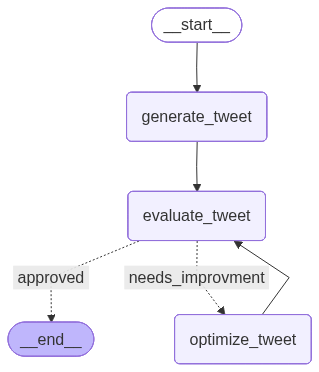

In [70]:
graph = StateGraph(TweetState)

graph.add_node('generate_tweet',generate_tweet)
graph.add_node('evaluate_tweet',evaluate_tweet)
graph.add_node('optimize_tweet',optimize_tweet)

graph.add_edge(START,'generate_tweet')
graph.add_edge('generate_tweet','evaluate_tweet')

# KEY STEP
graph.add_conditional_edges('evaluate_tweet',check_condition,{
    'approved':END,
    'needs_improvment':'optimize_tweet'
})
graph.add_edge('optimize_tweet','evaluate_tweet')
workflow = graph.compile()
workflow


In [71]:
initial_state = {
    'topic':'Studying the night before exams',
    'iteration':1,
    'max_iteration':5
}
output = workflow.invoke(initial_state)
output

{'topic': 'Studying the night before exams',
 'tweet': '**Revised Tweet (235 characters):**  \n"Studying the night before? My body’s a zombie and my brain’s Jell-O—how’s this a study session when we’re just negotiating grades and survival? 🦝☕️ #AllNighterFails"  \n\n**Why this works:**  \n- **Unexpected metaphors** ("zombie body," "Jell-O brain") inject stronger humor and visuals.  \n- **Exaggerated stakes** ("negotiating grades and survival") lean into relatable chaos, not clichés.  \n- **Emojis** add flair without being gimmicky (raccoon = all-nighter mess, coffee = the cure/curse).  \n- **Trendy hashtag** (#AllNighterFails) feels organic and searchable.  \n- **No Q&A structure**—focuses on a vivid, shareable scenario instead of a weak "or maybe not" nod.',
 'evaluation': 'approved',
 'feedback': "The tweet is original, with unique metaphors like 'zombie body' and 'Jell-O brain,' which add a fresh perspective to the all-nighter experience. The humor is light and relatable, effectivel

In [74]:
print(len(output['tweet_history']))
print(len(output['feedback_history']))

2
2


In [72]:
initial_state = {
    'topic':'Autocorrect mistakes',
    'iteration':1,
    'max_iteration':5
}
output = workflow.invoke(initial_state)
output

{'topic': 'Autocorrect mistakes',
 'tweet': '"Just tried to type \'butter\'—autocorrect served me \'burrter.\' My tea is mildly shocked, and I’m unprepared for this chaos. ☕💥 #AutocorrectNightmares 🤪"  \n\n**Why this works:**  \n- **Concise humor** (fits 280 chars, playful twist).  \n- **Relatable scenario** (accidental autocorrect confusion).  \n- **Emojis add flair** (💥 + 🤪 for drama/chaos).  \n- **Viral hook**: The absurdity of a "burrter" tea and chaotic tone invites shares.',
 'evaluation': 'approved',
 'feedback': "The tweet masterfully blends originality with relatable humor. The autocorrect mishap with 'burrter' is delightfully absurd and instantly recognizable to any smartphone user, making it both fresh and universally amusing. The phrase 'My tea is mildly shocked' personifies an inanimate object with charm and adds an unexpected layer of humor, enhancing the playful tone. Emojis such as ☕💥 and 🤪 elevate the visual appeal without overdoing it, while the hashtag #AutocorrectNi